# 1. Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. Load and Prepare Data

In [2]:
TRAIN_URL = 'http://ufldl.stanford.edu/housenumbers/train_32x32.mat'
TEST_URL = 'http://ufldl.stanford.edu/housenumbers/test_32x32.mat'

train_path = keras.utils.get_file('train_32x32.mat', origin=TRAIN_URL)
test_path = keras.utils.get_file('test_32x32.mat', origin=TEST_URL)

train_mat = loadmat(train_path)
test_mat = loadmat(test_path)

x_train = train_mat['X']
x_test = test_mat['X']

# The original shape is (32, 32, 3, N). Move the sample axis to the front.
x_train = np.transpose(x_train, (3, 0, 1, 2)).astype('float32') / 255.0
x_test = np.transpose(x_test, (3, 0, 1, 2)).astype('float32') / 255.0

print('Training data shape:', x_train.shape)
print('Test data shape:', x_test.shape)
print('Image min/max:', x_train.min(), x_train.max())

182040794/182040794 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
64275384/64275384 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data shape: (73257, 32, 32, 3)
Test data shape: (26032, 32, 32, 3)
Image min/max: 0.0 1.0


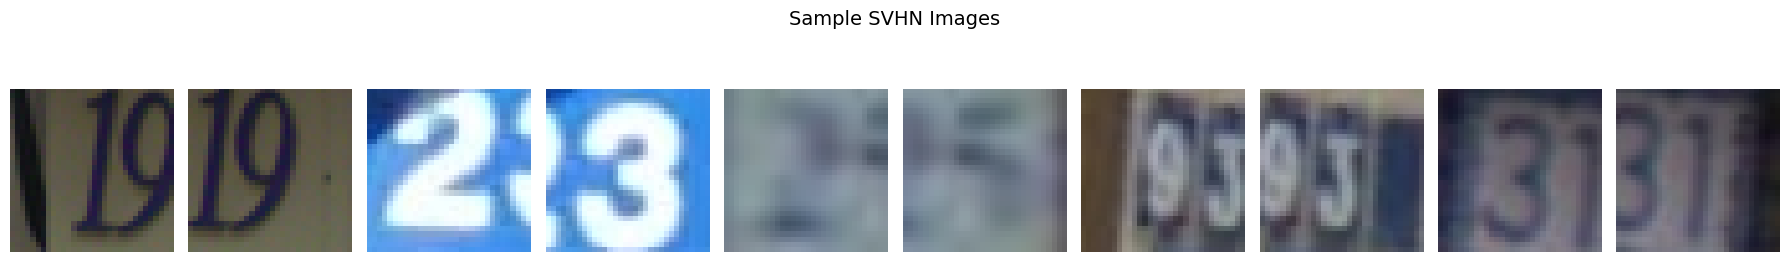

In [4]:
def show_sample_images(images, num_images=10):
    plt.figure(figsize=(18, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.suptitle('Sample SVHN Images', fontsize=14)
    plt.tight_layout()
    plt.show()

show_sample_images(x_train)

# 3. Autoencoder Architecture

In [5]:
def build_autoencoder(latent_dim):
    encoder_inputs = keras.Input(shape=(32, 32, 3), name='encoder_input')

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(encoder_inputs)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, name='latent_vector')(x)

    encoder = keras.Model(encoder_inputs, latent, name=f'encoder_latent_{latent_dim}')

    decoder_inputs = keras.Input(shape=(latent_dim,), name='decoder_input')
    x = layers.Dense(8 * 8 * 128, activation='relu')(decoder_inputs)
    x = layers.Reshape((8, 8, 128))(x)
    x = layers.Conv2DTranspose(128, 3, strides=1, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
    decoder_outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same', name='decoder_output')(x)

    decoder = keras.Model(decoder_inputs, decoder_outputs, name=f'decoder_latent_{latent_dim}')

    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = keras.Model(encoder_inputs, autoencoder_outputs, name=f'autoencoder_latent_{latent_dim}')
    autoencoder.compile(optimizer='adam', loss='mse')

    return encoder, decoder, autoencoder

encoder_64, decoder_64, autoencoder_64 = build_autoencoder(latent_dim=64)
autoencoder_64.summary()

Model: "autoencoder_latent_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_latent_64 (Functional)  │ (None, 64)             │       617,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_latent_64 (Functional)  │ (None, 32, 32, 3)      │       773,187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,390,787 (5.31 MB)

 Trainable params: 1,390,787 (5.31 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Training

In [6]:
LATENT_DIMS = [64, 16]
EPOCHS = 20
BATCH_SIZE = 128

results = {}


In [7]:
for latent_dim in LATENT_DIMS:
    print(f'\nTraining autoencoder with latent size = {latent_dim}')
    encoder, decoder, autoencoder = build_autoencoder(latent_dim)

    callbacks = [
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ]

    history = autoencoder.fit(
        x_train,
        x_train,
        validation_data=(x_test, x_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=callbacks,
        verbose=1
    )

    results[latent_dim] = {
        'encoder': encoder,
        'decoder': decoder,
        'autoencoder': autoencoder,
        'history': history
        }


Training autoencoder with latent size = 64
Epoch 1/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 0.0095 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 2/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0027 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 3/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0021 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 4/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.0019 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 5/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.0017 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 6/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.0016 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 7/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - loss: 0.0015 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 8/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - loss: 0.0015 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 9/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss

# 5. Plot Training and Validation Loss

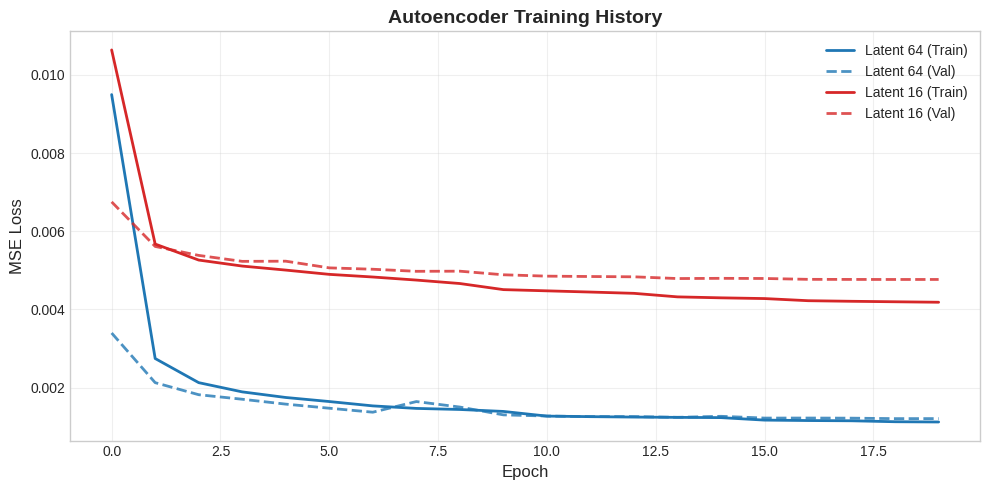

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 5))
colors = {
    64: '#1f77b4',  # blue
    16: '#d62728',  # red
}

for latent_dim in LATENT_DIMS:
    history = results[latent_dim]['history'].history
    color = colors[latent_dim]

    plt.plot(
        history['loss'],
        color=color,
        linewidth=2,
        label=f'Latent {latent_dim} (Train)'
    )
    plt.plot(
        history['val_loss'],
        color=color,
        linestyle='--',
        linewidth=2,
        alpha=0.8,
        label=f'Latent {latent_dim} (Val)'
    )

plt.title('Autoencoder Training History', fontsize=14, weight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Reconstruction Results


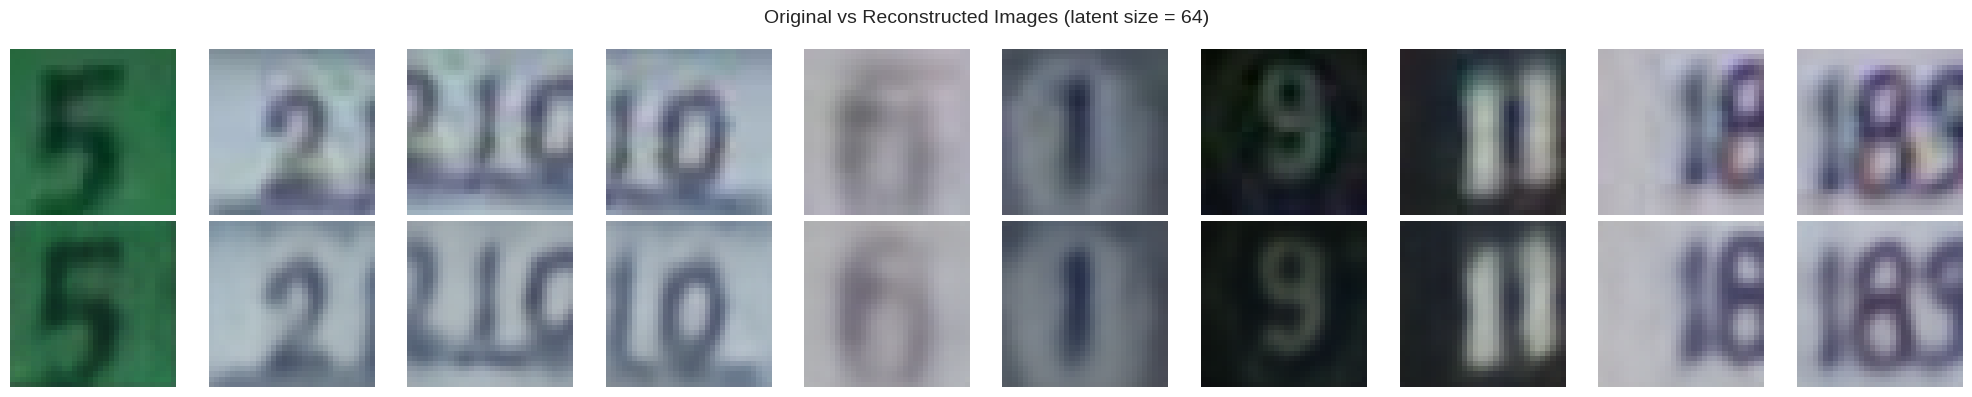

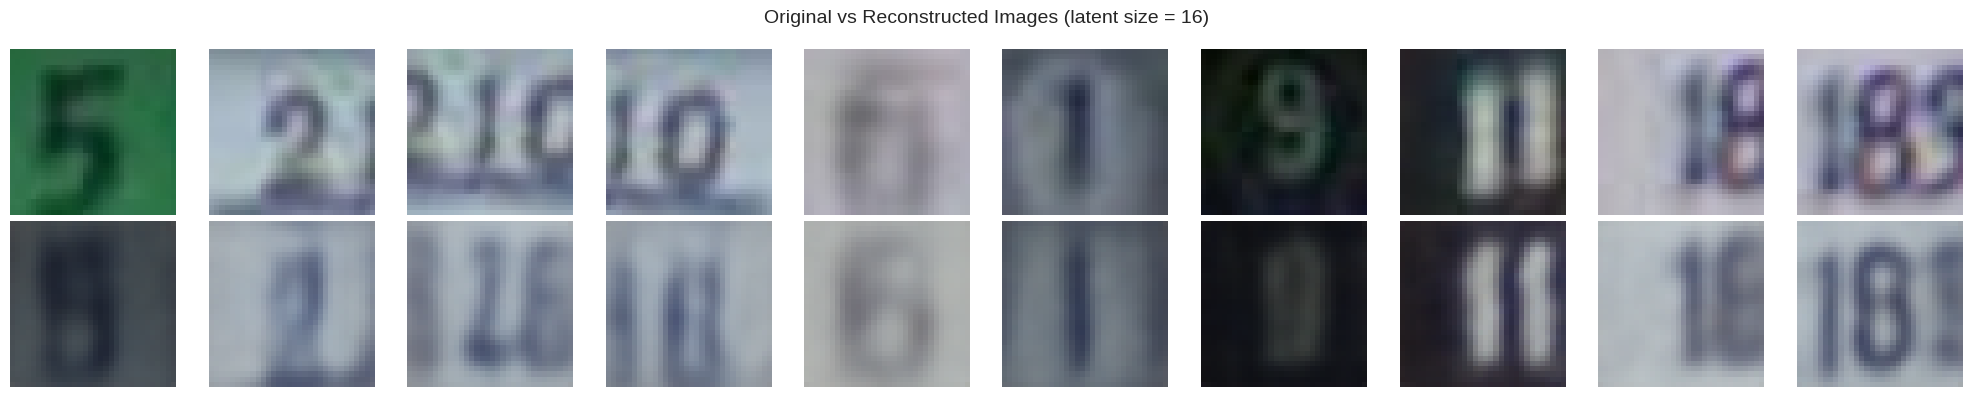

In [13]:
def show_reconstructions(model, images, num_images=10, title='Reconstruction Results'):
    sample_images = images[:num_images]
    reconstructed = model.predict(sample_images, verbose=0)

    plt.figure(figsize=(20, 4))
    for i in range(num_images):
        plt.subplot(2, num_images, i + 1)
        plt.imshow(sample_images[i])
        plt.axis('off')
        if i == 0:
            plt.ylabel('Original', fontsize=12)

        plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(np.clip(reconstructed[i], 0, 1))
        plt.axis('off')
        if i == 0:
            plt.ylabel('Reconstructed', fontsize=12)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

for latent_dim in LATENT_DIMS:
    show_reconstructions(
        results[latent_dim]['autoencoder'],
        x_test,
        num_images=10,
        title=f'Original vs Reconstructed Images (latent size = {latent_dim})'
    )

# 7. Latent Representation Extraction

In [11]:
sample_images = x_test[:5]

for latent_dim in LATENT_DIMS:
    encoder = results[latent_dim]['encoder']
    latent_vectors = encoder.predict(sample_images, verbose=0)

    print('=' * 70)
    print(f'Latent size: {latent_dim}')
    print('Latent representation shape:', latent_vectors.shape)
    print('Example latent vector (first sample):')
    print(latent_vectors[0])


Latent size: 64
Latent representation shape: (5, 64)
Example latent vector (first sample):
[-0.22687821 -0.05684431  0.399133   -0.12761809  0.21269682 -0.10439365
  0.37184143  0.29555738 -0.5474668   0.2057618  -0.24739978 -0.11559276
  0.1176783  -0.52928615  0.26651394  0.13755102 -0.9238226   0.21498328
  0.4764215   0.44018131 -0.10001685 -0.12907872 -0.5330072   0.62094665
  0.323457    0.23407775 -0.3428576   0.28005892  0.1601808  -0.12202206
  0.2527817  -0.27198675  0.07905284 -0.5546513   0.63312536 -0.1307863
 -0.49772394 -0.0182461   0.20493238  0.04135607  0.4294969  -0.3282678
 -0.39697844  0.06930728  0.60083807  0.11493251  0.53131664  0.04835857
 -0.27535978 -0.14695975  0.40424937 -0.6134663   0.9384383  -0.27109027
  0.16089481  0.33780625  0.6489045   0.41544744 -0.39532745  0.02582947
  0.49646118  0.07228193 -0.3246147  -0.45468804]
Latent size: 16
Latent representation shape: (5, 16)
Example latent vector (first sample):
[-0.1233473  -0.15249819 -0.20660672 -0.

# 8. Final Comparison

In [12]:
for latent_dim in LATENT_DIMS:
    final_val_loss = results[latent_dim]['history'].history['val_loss'][-1]
    print(f'Latent size {latent_dim}: final validation MSE = {final_val_loss:.6f}')

print('\nConclusion:')
print('- Larger latent dimensions usually preserve more image detail and improve reconstruction quality.')
print('- Smaller latent dimensions produce stronger compression, but some visual details may be lost.')
print('- Both settings demonstrate that the latent space preserves useful information because reconstruction is still possible.')

Latent size 64: final validation MSE = 0.001208
Latent size 16: final validation MSE = 0.004766

Conclusion:
- Larger latent dimensions usually preserve more image detail and improve reconstruction quality.
- Smaller latent dimensions produce stronger compression, but some visual details may be lost.
- Both settings demonstrate that the latent space preserves useful information because reconstruction is still possible.


# 9. Written Explanation

## 1. What a latent representation is?
  - A latent representation is a compressed feature vector learned by the encoder. It keeps the most important information from the input image in a smaller form.
## 2. How dimensionality reduction affects reconstruction quality?
  - When the latent dimension becomes smaller, the model has less capacity to store detailed information. As a result, fine textures and sharp edges may be lost, so reconstruction quality usually decreases.
## 3. What is the role of autoencoders in representation learning?
  - Autoencoders learn useful features without labels by forcing the network to reconstruct the input. This makes them a good tool for unsupervised representation learning, compression, denoising, and feature extraction.